Markdown
# Google+ Sosyal Ağı Üzerinde Kullanıcı Etkileşimlerinin ve Topluluk Yapılarının Analizi

---

## 📝 Proje Özeti ve Amacı
Bu çalışma, **SNAP (Stanford Network Analysis Project)** üzerinden alınan Google+ ego ağlarını kullanarak, dijital bir sosyal ağın topolojik yapısını modellemeyi amaçlamaktadır. Proje kapsamında;
* Kullanıcılar arası bağlantıların yoğunluğu,
* Ağdaki en kritik ve nüfuzlu aktörlerin (hubs) tespiti,
* Doğal topluluk yapılarının ve gruplaşmaların analizi,
* Ağın olası saldırılara veya bilgi kaybına karşı dayanıklılığı incelenmektedir.

**Veri Seti:** Google+ Ego Networks (.edges dosyaları)

## 1. Veri Seti ve Ağ Modelleme
Bu aşamada, Google+ platformuna ait üç farklı ego ağını temsil eden .edges dosyaları birleştirilerek kapsamlı bir yönlü graf (DiGraph) modeli oluşturulmuştur. Analiz sürecinde; Python'un networkx kütüphanesi kullanılarak veriler işlenmiş, ağın düğüm (kullanıcı) ve kenar (etkileşim) sayıları gibi temel topolojik özellikleri hesaplanmıştır. Bu bölüm, ağın genel yapısını nicel olarak anlamamıza ve ilerleyen aşamalardaki merkezilik analizlerine temel oluşturmamıza olanak tanır.

In [12]:
import networkx as nx

dosyalar = [
    'SNA_Proje/100535338638690515335.edges',
    'SNA_Proje/100637660947564674695.edges',
    'SNA_Proje/117412175333096244275.edges'
]

# Yönlü grafımızı (DiGraph) oluşturuyoruz
G_combined = nx.DiGraph()

print("Dosyalar okunuyor ve ağ birleştiriliyor, lütfen bekleyin...")

# Her bir dosyayı okuyup ana grafa ekliyoruz
for dosya in dosyalar:
    G_temp = nx.read_edgelist(dosya, create_using=nx.DiGraph())
    G_combined = nx.compose(G_combined, G_temp)

#Temel Ağ Ölçütleri
dugum_sayisi = G_combined.number_of_nodes()
kenar_sayisi = G_combined.number_of_edges()
yogunluk = nx.density(G_combined)

# Ortalama derece (Toplam bağlantı sayısının, toplam kullanıcıya oranı)
ortalama_derece = sum(dict(G_combined.degree()).values()) / dugum_sayisi

print("\n Ağ Başarıyla Kuruldu!")
print(f"Düğüm (Kullanıcı) Sayısı: {dugum_sayisi}")
print(f"Kenar (Bağlantı) Sayısı: {kenar_sayisi}")
print(f"Ağ Yoğunluğu (Density): {yogunluk:.5f}")
print(f"Ortalama Derece: {ortalama_derece:.2f}")

Dosyalar okunuyor ve ağ birleştiriliyor, lütfen bekleyin...

 Ağ Başarıyla Kuruldu!
Düğüm (Kullanıcı) Sayısı: 1687
Kenar (Bağlantı) Sayısı: 72001
Ağ Yoğunluğu (Density): 0.02531
Ortalama Derece: 85.36



1. Düğüm Listesi (V) - İlk 5 Örnek:
['104605946488794124557', '103809839833065657064', '111719533163202900131', '115514397255079403751', '100348228053016261723']

2. Kenar Listesi (E) - İlk 5 Örnek:
[('104605946488794124557', '103809839833065657064'), ('104605946488794124557', '104987932455782713675'), ('104605946488794124557', '111499908439497508351'), ('104605946488794124557', '102034052532213921839'), ('104605946488794124557', '110394599356932147330')]

3. Komşuluk Listesi (İlk 3 Düğüm İçin):
Düğüm 104605946488794124557 -> Takip Ettikleri: ['103809839833065657064', '104987932455782713675', '111499908439497508351', '102034052532213921839', '110394599356932147330']...
Düğüm 103809839833065657064 -> Takip Ettikleri: []...
Düğüm 111719533163202900131 -> Takip Ettikleri: ['115514397255079403751', '105890906575573863227', '115176155345443475500', '115242081056296652095', '112374836634096795698']...

4. Ağ Grafiği Oluşturuluyor...


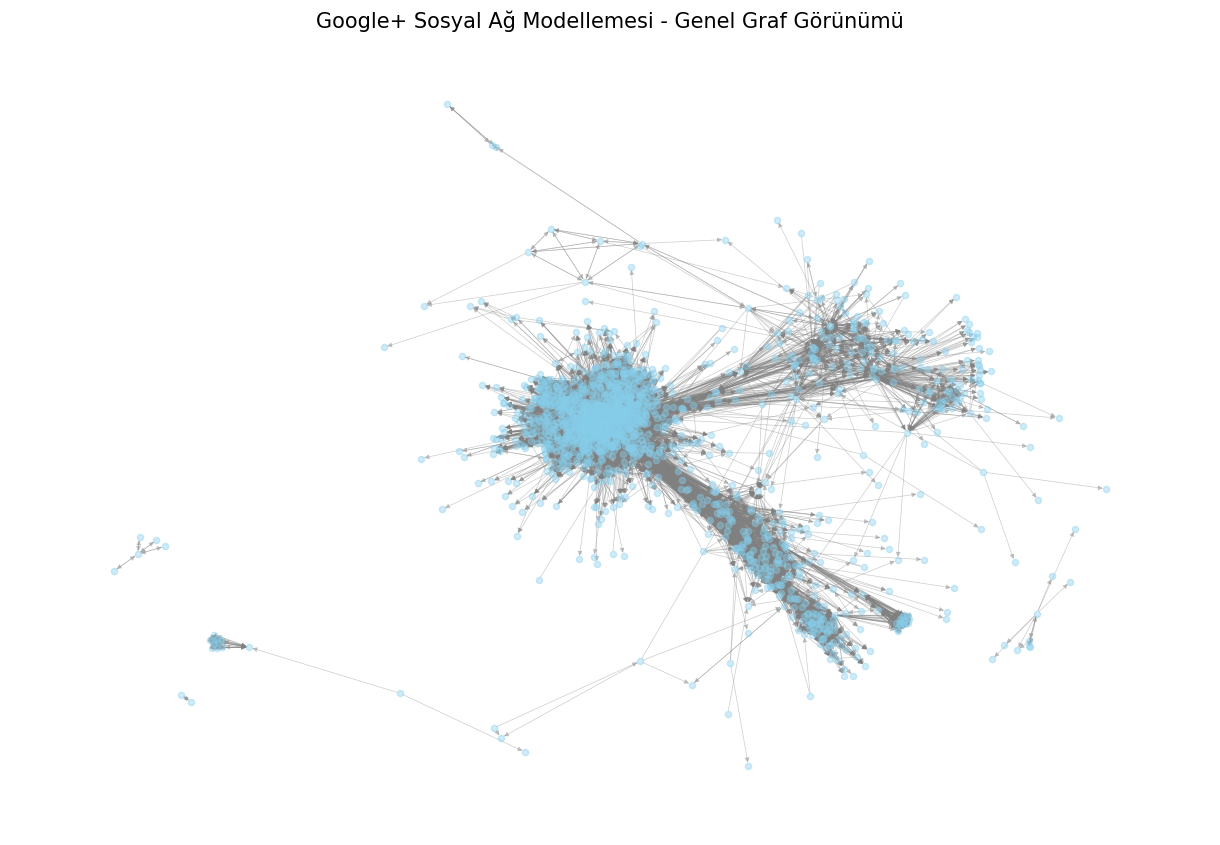

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

print(f"\n1. Düğüm Listesi (V) - İlk 5 Örnek:")
print(list(G_combined.nodes())[:5])

print(f"\n2. Kenar Listesi (E) - İlk 5 Örnek:")
print(list(G_combined.edges())[:5])

print(f"\n3. Komşuluk Listesi (İlk 3 Düğüm İçin):")
for node in list(G_combined.nodes())[:3]:
    neighbors = list(G_combined.neighbors(node))
    print(f"Düğüm {node} -> Takip Ettikleri: {neighbors[:5]}...")

# Görselleştirme kısmı
print("\n4. Ağ Grafiği Oluşturuluyor...")
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_combined, k=0.15, seed=42)

nx.draw(G_combined, pos,
        node_size=20,
        node_color='skyblue',
        with_labels=False,
        edge_color='gray',
        alpha=0.4,
        width=0.5,
        arrowsize=7)

plt.title("Google+ Sosyal Ağ Modellemesi - Genel Graf Görünümü", fontsize=15)
plt.show()

## 2.Ağın Büyüklüğü ve Yapısal Özellikleri
Ağın genel karakteristiğini belirlemek adına yoğunluk, ortalama derece ve kümeleme katsayısı gibi değerler incelenmiştir. Bu bölümde:

Yoğunluk (Density): Ağdaki potansiyel bağlantıların ne kadarının gerçekleştiğini,

Kümeleme Katsayısı (Clustering Coefficient): Kullanıcıların birbirleriyle ne kadar sıkı gruplar oluşturduğunu,

Ağ Çapı (Diameter): En uzak iki kullanıcı arasındaki en kısa mesafeyi temsil eder.

Ayrıca hazırlanan Derece Dağılımı Grafiği, ağın "ölçekten bağımsız" (scale-free) bir yapıda olup olmadığını ve "hub" olarak adlandırılan çok yüksek bağlantılı lider kullanıcıların varlığını görselleştirmektedir.

Düğüm Sayısı: 1687
Kenar Sayısı: 72001
Ağ Yoğunluğu (Density): 0.025314
Ortalama Derece: 85.36
Kümeleme Katsayısı: 0.3715
Ağ Çapı (Diameter): 9


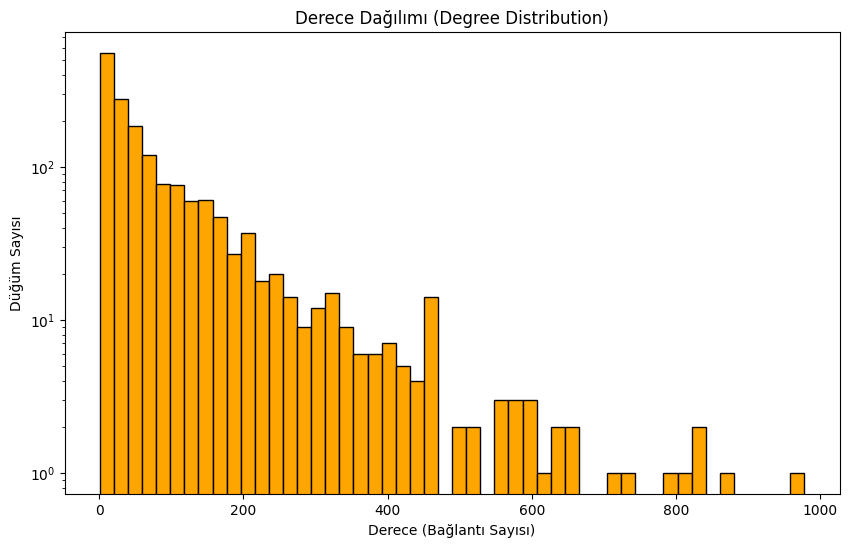

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Temel Sayısal Değerler
dugum_sayisi = G_combined.number_of_nodes()
kenar_sayisi = G_combined.number_of_edges()
yogunluk = nx.density(G_combined)

# 2. Derece Analizi
dereceler = dict(G_combined.degree())
ortalama_derece = sum(dereceler.values()) / dugum_sayisi

# 3. Kümeleme ve Yol Ölçütleri
# Ortalama kümeleme katsayısı (Ağın mahalle yapısını ölçer)
kumeleme_katsayisi = nx.average_clustering(G_combined)

# Çap (Diameter) Hesabı
# Not: Yönlü ve kopuk parçalı ağlarda çap sonsuz çıkabilir.
# Bu yüzden en büyük zayıf bağlı bileşen üzerinden hesaplanır.
G_un = G_combined.to_undirected()
en_buyuk_bilesen = max(nx.connected_components(G_un), key=len)
subgraph = G_un.subgraph(en_buyuk_bilesen)
cap = nx.diameter(subgraph)

print(f"Düğüm Sayısı: {dugum_sayisi}")
print(f"Kenar Sayısı: {kenar_sayisi}")
print(f"Ağ Yoğunluğu (Density): {yogunluk:.6f}")
print(f"Ortalama Derece: {ortalama_derece:.2f}")
print(f"Kümeleme Katsayısı: {kumeleme_katsayisi:.4f}")
print(f"Ağ Çapı (Diameter): {cap}")

# 4. Derece Dağılımı Grafiği (Hub Düğüm Kontrolü)
plt.figure(figsize=(10, 6))
plt.hist(dereceler.values(), bins=50, color='orange', edgecolor='black')
plt.title('Derece Dağılımı (Degree Distribution)')
plt.xlabel('Derece (Bağlantı Sayısı)')
plt.ylabel('Düğüm Sayısı')
plt.yscale('log') # Logaritmik ölçek hub düğümleri daha iyi gösterir
plt.show()

## 3. Merkezilik (Centrality) Analizi: Kritik Aktörlerin Tespiti
Sosyal ağlarda her kullanıcı aynı öneme sahip değildir. Bu bölümde 5 farklı matematiksel model kullanılarak "en önemli" kullanıcılar belirlenmiştir:
* **Degree:** En popüler kullanıcılar.
* **Betweenness:** Gruplar arası bilgi akışını kontrol eden köprü kullanıcılar.
* **PageRank:** Otorite ve güvenilirliği yüksek hesaplar.
* **Closeness:** Bilgiyi en hızlı yayan merkezdeki kişiler.
* **Eigenvector:** Etkili kişilerle bağlantısı olan nüfuzlu aktörler.

In [15]:
import pandas as pd
import networkx as nx

# 1. Merkezilik Metriklerinin Hesaplanması
# Not: Ağın büyüklüğü nedeniyle Betweenness hesabı 1-2 dakika sürebilir.
print("Merkezilik analizleri hesaplanıyor, lütfen bekleyin...")

degree_cen = nx.degree_centrality(G_combined)
betweenness_cen = nx.betweenness_centrality(G_combined)
closeness_cen = nx.closeness_centrality(G_combined)
# Eigenvector için max_iter'i artırıyoruz ki sonuç kesinleşsin
eigenvector_cen = nx.eigenvector_centrality(G_combined, max_iter=1000)
pagerank_cen = nx.pagerank(G_combined)

# 2. Sonuçları Tablolaştırmak İçin Yardımcı Fonksiyon
def ilk_bes_getir(merkezilik_sozlugu, kolon_adi):
    # Skorları büyükten küçüğe sıralayıp ilk 5'i alır
    sirali = sorted(merkezilik_sozlugu.items(), key=lambda item: item[1], reverse=True)[:5]
    return pd.DataFrame(sirali, columns=['Kullanıcı ID', kolon_adi])

# 3. Her Metrik İçin Tabloların Oluşturulması
df_degree = ilk_bes_getir(degree_cen, 'Derece Skoru (Popülarite)')
df_between = ilk_bes_getir(betweenness_cen, 'Arasındalık Skoru (Köprü)')
df_closeness = ilk_bes_getir(closeness_cen, 'Yakınlık Skoru (Hız)')
df_eigen = ilk_bes_getir(eigenvector_cen, 'Özvektör Skoru (Etki)')
df_pagerank = ilk_bes_getir(pagerank_cen, 'PageRank Skoru (Otorite)')

# 4. Sonuçların Ekrana Yazdırılması
print("\n" + "="*30)
print("5. MERKEZİLİK ANALİZİ SONUÇLARI")
print("="*30)

print("\n[DEGREE CENTRALITY - EN POPÜLERLER]")
print(df_degree)

print("\n[BETWEENNESS CENTRALITY - KÖPRÜ DÜĞÜMLER]")
print(df_between)

print("\n[CLOSENESS CENTRALITY - HIZLI YAYICILAR]")
print(df_closeness)

print("\n[EIGENVECTOR CENTRALITY - ETKİLİ KİŞİLER]")
print(df_eigen)

print("\n[PAGERANK - OTORİTE HESAPLAR]")
print(df_pagerank)

# 5. Rapor İçin Özet Yorum Yazdırma
en_populer = df_degree.iloc[0,0]
en_stratejik_kopru = df_between.iloc[0,0]

print("\n" + "-"*30)
print(f"ANALİZ ÖZETİ VE YORUM:")
print(f"- Ağın en popüler (en çok takip edilen) ismi: {en_populer}")
print(f"- Farklı grupları birbirine bağlayan en kritik köprü: {en_stratejik_kopru}")
print(f"- Eğer {en_stratejik_kopru} ID'li kullanıcı ağdan ayrılırsa, bilgi akışı ciddi zarar görür.")

Merkezilik analizleri hesaplanıyor, lütfen bekleyin...

5. MERKEZİLİK ANALİZİ SONUÇLARI

[DEGREE CENTRALITY - EN POPÜLERLER]
            Kullanıcı ID  Derece Skoru (Popülarite)
0  111091089527727420853                   0.580071
1  102034052532213921839                   0.521352
2  104405539079062799451                   0.491696
3  113116318008017777871                   0.488138
4  100008438047495460295                   0.478055

[BETWEENNESS CENTRALITY - KÖPRÜ DÜĞÜMLER]
            Kullanıcı ID  Arasındalık Skoru (Köprü)
0  113116318008017777871                   0.076725
1  112374836634096795698                   0.055770
2  111091089527727420853                   0.054360
3  101793532287583914396                   0.046390
4  102472204830503422684                   0.034621

[CLOSENESS CENTRALITY - HIZLI YAYICILAR]
            Kullanıcı ID  Yakınlık Skoru (Hız)
0  109813896768294978296              0.317002
1  113116318008017777871              0.307558
2  107117483540235115863 

## 4. Derece Merkezilik (Degree Centrality) Yoğunluk Haritası
Bu görselleştirme, ağdaki kullanıcıların doğrudan bağlantı sayılarını (popülarite) temsil eder. Düğüm boyutları ve renklerin "Plasma" paletindeki parlaklığı, ilgili kullanıcının ağdaki takipçi sayısının yüksekliğini simgelemektedir.

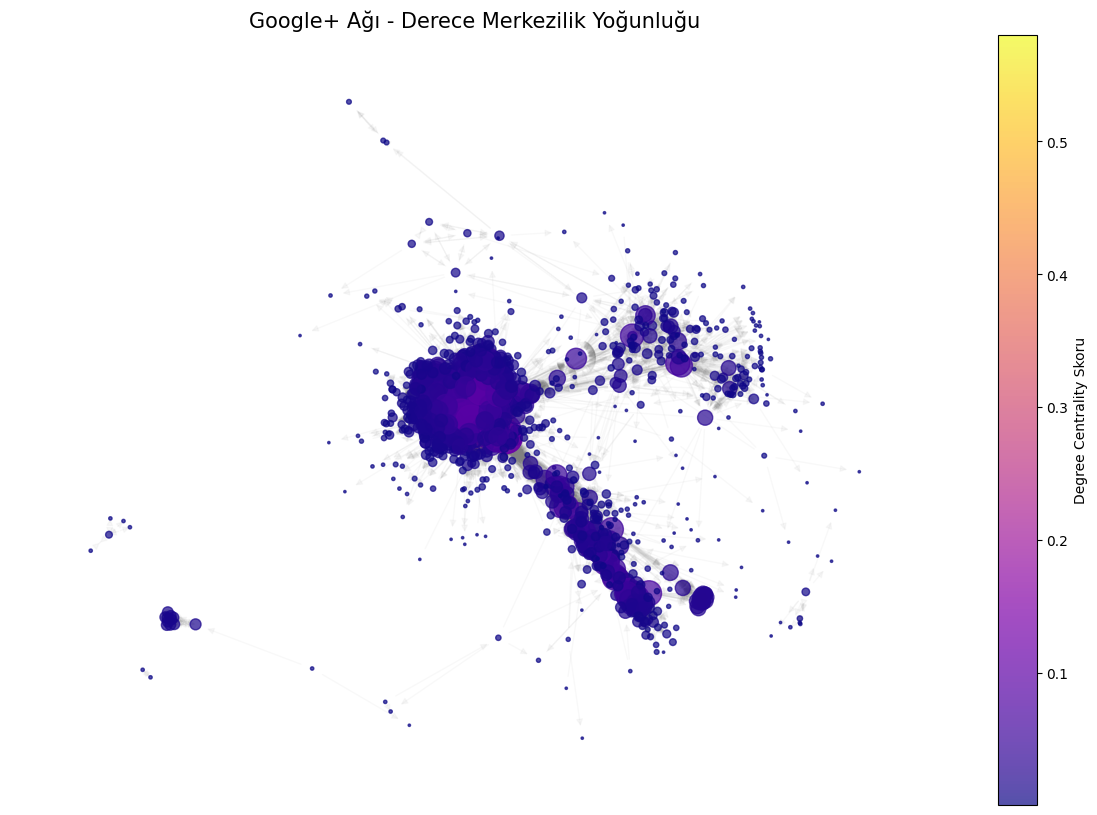

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Skorları al ve listeye çevir
degree_dict = nx.degree_centrality(G_combined)
degree_values = list(degree_dict.values())

plt.figure(figsize=(15, 10))
ax = plt.gca() # Mevcut ekseni al

# 2. Çizim (Düğümlerin renklenmesi için node_color=degree_values olmalı)
nodes = nx.draw_networkx_nodes(G_combined, pos,
                               node_size=[v * 5000 for v in degree_values],
                               node_color=degree_values,
                               cmap=plt.cm.plasma,
                               alpha=0.7,
                               ax=ax)

nx.draw_networkx_edges(G_combined, pos, alpha=0.05, edge_color='gray', ax=ax)

# 3. Colorbar hatasını çözen kısım:
# 'ax=ax' parametresi colorbar'ın nereye ekleneceğini netleştirir
plt.colorbar(nodes, ax=ax, label='Degree Centrality Skoru')

plt.title("Google+ Ağı - Derece Merkezilik Yoğunluğu", fontsize=15)
plt.axis('off')
plt.show()

## 5. Arasındalık Merkezilik (Betweenness Centrality) Yoğunluk Haritası
Ağdaki "köprü" aktörleri belirlemek için kullanılan bu haritada, farklı toplulukları birbirine bağlayan stratejik düğümler vurgulanmıştır. Yüksek skora sahip düğümler, ağdaki bilgi akışının geçiş noktalarını temsil eder.

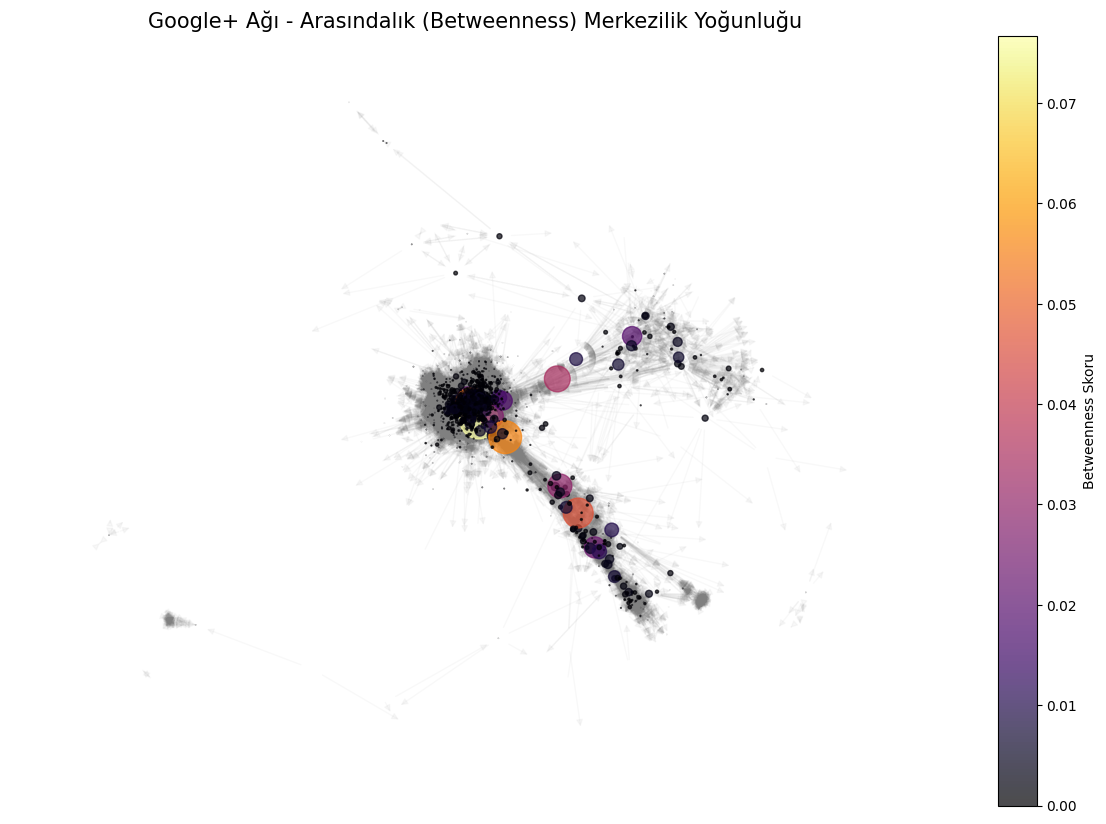

In [17]:
# 1. Skorları al
betweenness_dict = nx.betweenness_centrality(G_combined)
betweenness_values = list(betweenness_dict.values())

plt.figure(figsize=(15, 10))
ax = plt.gca()

# 2. Çizim (Betweenness değerleri çok küçük olduğu için 10000 ile çarptık)
nodes = nx.draw_networkx_nodes(G_combined, pos,
                               node_size=[v * 10000 for v in betweenness_values],
                               node_color=betweenness_values,
                               cmap=plt.cm.inferno, # Köprüleri vurgulamak için ateş renkleri
                               alpha=0.7,
                               ax=ax)

nx.draw_networkx_edges(G_combined, pos, alpha=0.05, edge_color='gray', ax=ax)

# 3. Colorbar
plt.colorbar(nodes, ax=ax, label='Betweenness Skoru')

plt.title("Google+ Ağı - Arasındalık (Betweenness) Merkezilik Yoğunluğu", fontsize=15)
plt.axis('off')
plt.show()

## 6. PageRank (Otorite) Yoğunluk Haritası
Google'ın algoritması temel alınarak hazırlanan bu harita, sadece bağlantı sayısına değil, bağlantı kurulan kişilerin kalitesine (otoritesine) odaklanır. Yeşil ve sarı tonlardaki düğümler ağın en prestijli hesaplarını gösterir.

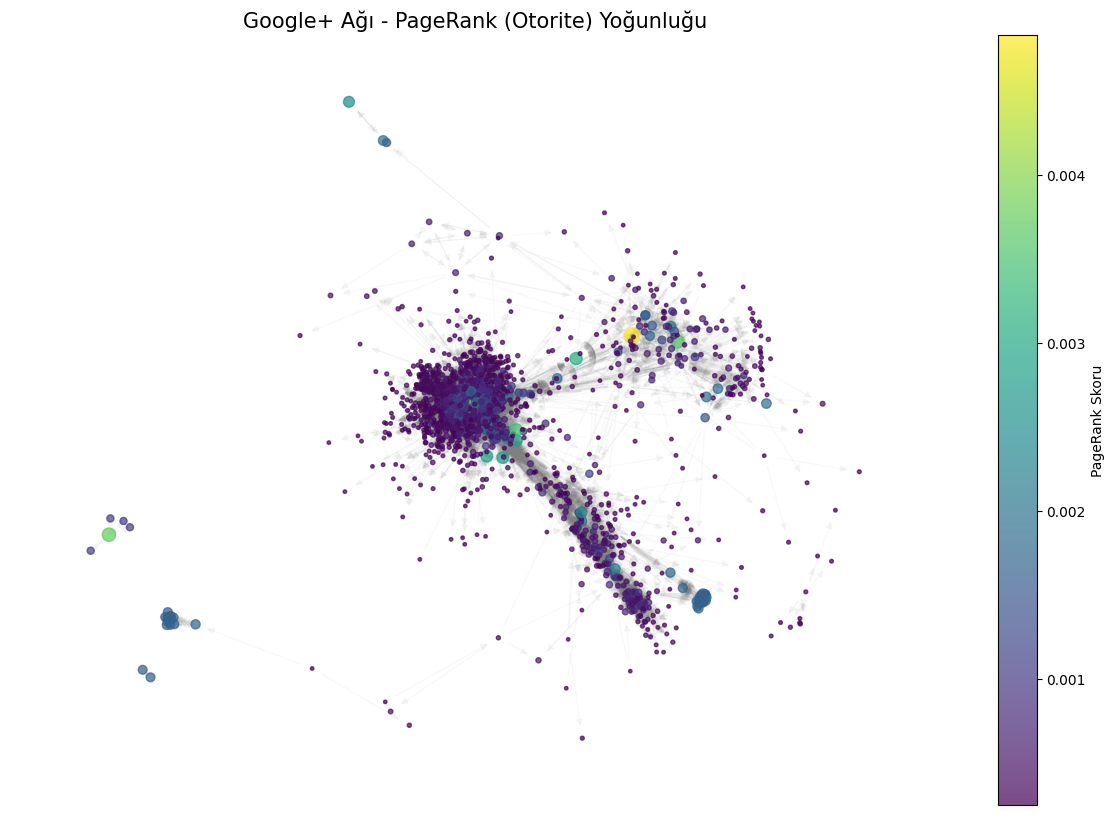

In [18]:
# 1. Skorları al
pagerank_dict = nx.pagerank(G_combined)
pagerank_values = list(pagerank_dict.values())

plt.figure(figsize=(15, 10))
ax = plt.gca()

# 2. Çizim (PageRank değerleri için 25000 çarpanı idealdir)
nodes = nx.draw_networkx_nodes(G_combined, pos,
                               node_size=[v * 25000 for v in pagerank_values],
                               node_color=pagerank_values,
                               cmap=plt.cm.viridis, # Otorite için yeşil/mavi tonları
                               alpha=0.7,
                               ax=ax)

nx.draw_networkx_edges(G_combined, pos, alpha=0.05, edge_color='gray', ax=ax)

# 3. Colorbar
plt.colorbar(nodes, ax=ax, label='PageRank Skoru')

plt.title("Google+ Ağı - PageRank (Otorite) Yoğunluğu", fontsize=15)
plt.axis('off')
plt.show()

## 7. Yakınlık Merkezilik (Closeness Centrality) Yoğunluk Haritası
Bu harita, bir kullanıcının ağdaki diğer tüm kullanıcılara ne kadar kısa sürede ulaşabileceğini ölçer. Merkeze yakın ve yayılım hızı yüksek olan düğümler daha parlak renklerle (Magma paleti) ayrıştırılmıştır.

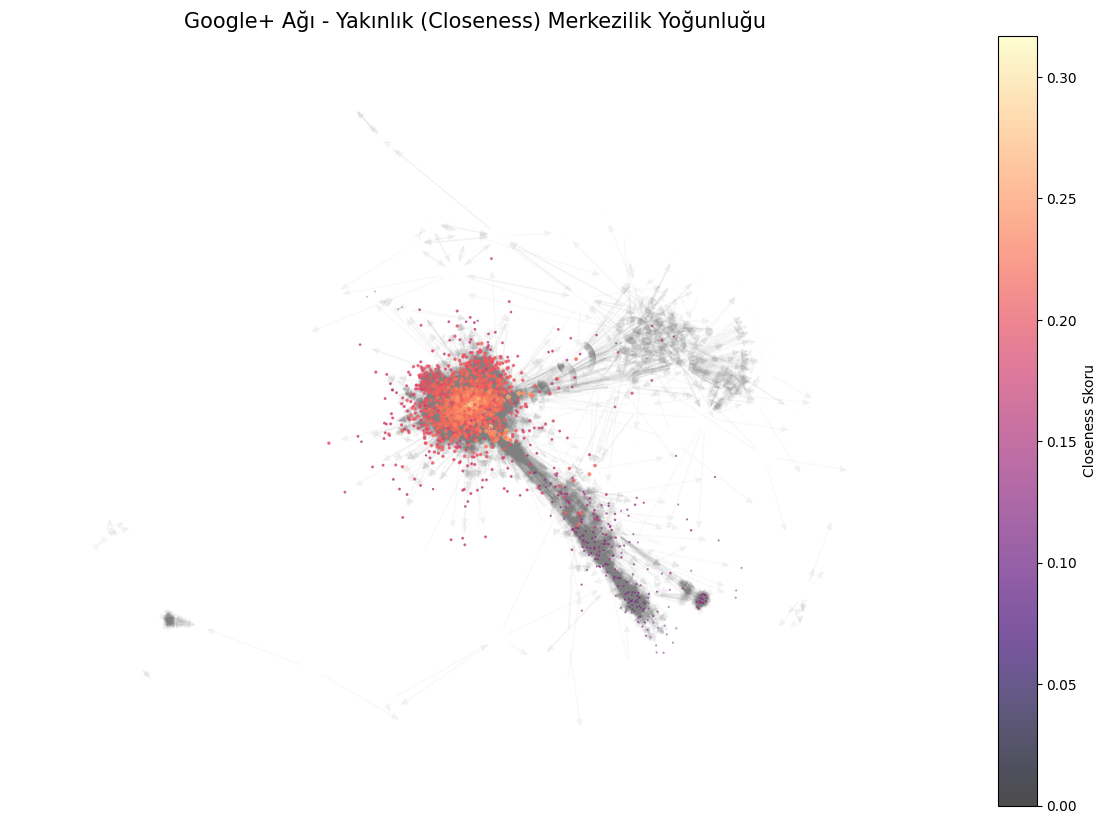

In [19]:
# 1. Skorları al
closeness_dict = nx.closeness_centrality(G_combined)
closeness_values = list(closeness_dict.values())

plt.figure(figsize=(15, 10))
ax = plt.gca()

# 2. Çizim (Closeness değerleri birbirine yakındır, farkı görmek için v**4 kullandık)
nodes = nx.draw_networkx_nodes(G_combined, pos,
                               node_size=[(v**4) * 1500 for v in closeness_values],
                               node_color=closeness_values,
                               cmap=plt.cm.magma,
                               alpha=0.7,
                               ax=ax)

nx.draw_networkx_edges(G_combined, pos, alpha=0.05, edge_color='gray', ax=ax)

# 3. Colorbar
plt.colorbar(nodes, ax=ax, label='Closeness Skoru')

plt.title("Google+ Ağı - Yakınlık (Closeness) Merkezilik Yoğunluğu", fontsize=15)
plt.axis('off')
plt.show()

## 8. Özvektör Merkezilik (Eigenvector Centrality) Yoğunluk Haritası
Özvektör analizi, bir kullanıcının "önemli kişilerle olan bağlantısını" ölçer. Bu haritada büyük görünen düğümler, kendisi kadar bağlantı kurduğu çevresinin de güçlü olduğunu kanıtlayan nüfuzlu aktörlerdir.

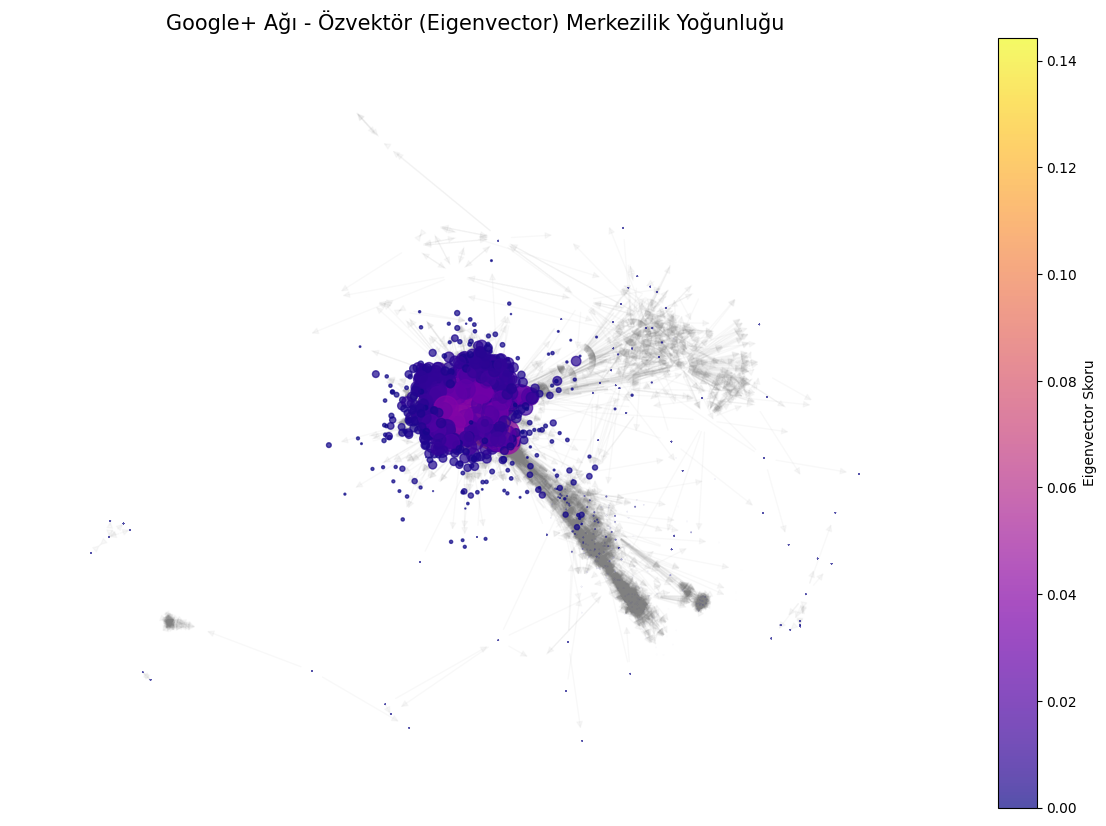

In [20]:
# 1. Skorları al
eigenvector_dict = nx.eigenvector_centrality(G_combined, max_iter=1000)
eigenvector_values = list(eigenvector_dict.values())

plt.figure(figsize=(15, 10))
ax = plt.gca()

# 2. Çizim
nodes = nx.draw_networkx_nodes(G_combined, pos,
                               node_size=[v * 8000 for v in eigenvector_values],
                               node_color=eigenvector_values,
                               cmap=plt.cm.plasma,
                               alpha=0.7,
                               ax=ax)

nx.draw_networkx_edges(G_combined, pos, alpha=0.05, edge_color='gray', ax=ax)

# 3. Colorbar
plt.colorbar(nodes, ax=ax, label='Eigenvector Skoru')

plt.title("Google+ Ağı - Özvektör (Eigenvector) Merkezilik Yoğunluğu", fontsize=15)
plt.axis('off')
plt.show()

## 9. Merkezilik Metrikleri Arasındaki İlişkiler (Korelasyon Analizi)
Analiz edilen tüm merkezilik ölçütlerinin birbiriyle ne kadar uyumlu olduğunu anlamak için bir **Isı Haritası (Heatmap)** oluşturulmuştur. 1.00'a yaklaşan değerler, iki metriğin aynı kullanıcıları benzer şekilde "önemli" olarak nitelendirdiğini gösterir. Bu tablo, ağdaki popüler kullanıcıların aynı zamanda stratejik birer köprü olup olmadıklarını matematiksel olarak kanıtlar.

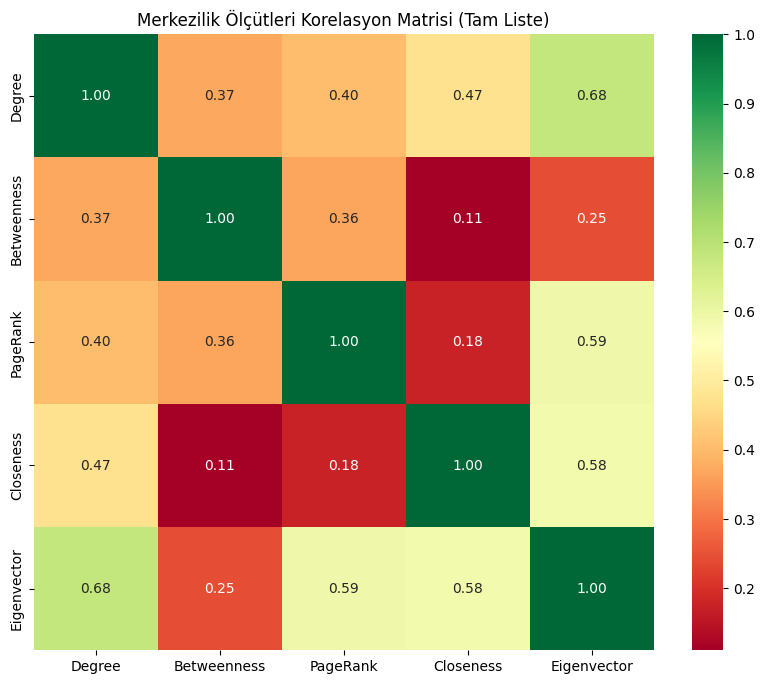

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# 1. Tüm merkezilik ölçütlerini hesaplayalım -
data = {
    'Degree': list(dict(G_combined.degree()).values()),
    'Betweenness': list(nx.betweenness_centrality(G_combined).values()),
    'PageRank': list(nx.pagerank(G_combined).values()),
    'Closeness': list(nx.closeness_centrality(G_combined).values()),
    'Eigenvector': list(nx.eigenvector_centrality(G_combined, max_iter=1000).values())
}

df_corr = pd.DataFrame(data)

# 2. Isı haritasını çiziyoruz
plt.figure(figsize=(10, 8))
# Korelasyon matrisini hesaplayıp çizdiriyoruz
sns.heatmap(df_corr.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Merkezilik Ölçütleri Korelasyon Matrisi (Tam Liste)")
plt.show()

## 10. Topluluk Tespiti (Community Detection)
Ağ içindeki kullanıcıların hangi alt gruplara (community) ayrıldığını tespit etmek için **Louvain Algoritması** kullanılmıştır. Modülerlik skoru ile bu gruplaşmanın ne kadar belirgin olduğu ölçülmektedir.

Tespit Edilen Topluluk Sayısı: 11
Modülerlik Skoru: 0.2971
En Büyük Topluluk: 1. Grup (459 kişi)


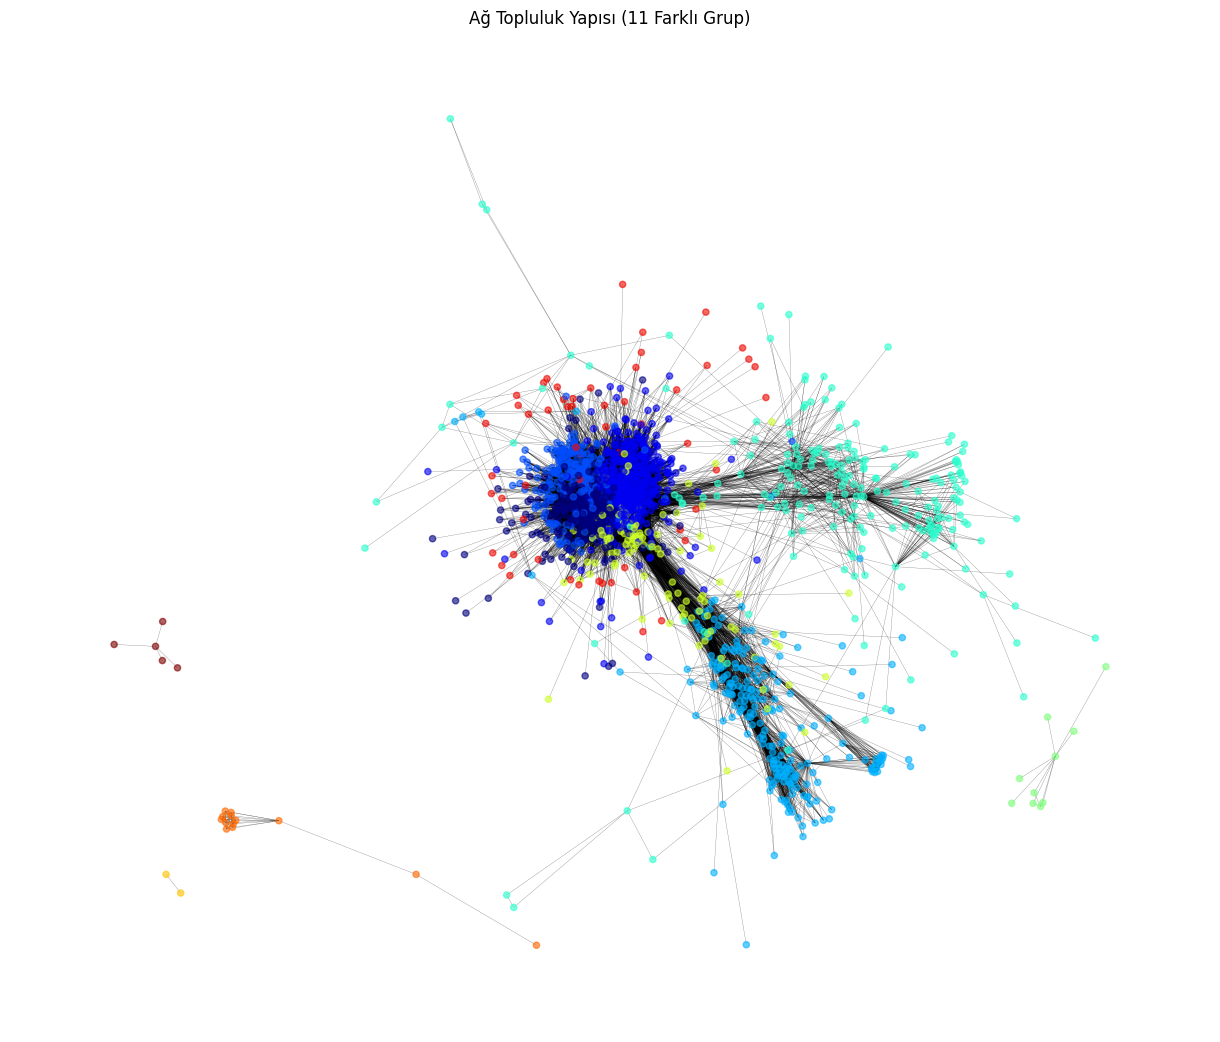

In [27]:
import networkx as nx
import community.community_louvain as community_louvain # pip install python-louvain
import matplotlib.pyplot as plt

# 1. Louvain Algoritması için ağın yönsüz bir kopyasını oluşturuyoruz
# (Louvain genellikle yönsüz ağlarda daha stabil sonuç verir)
G_undirected = G_combined.to_undirected()

# 2. Toplulukların Tespit Edilmesi
partition = community_louvain.best_partition(G_undirected)

# 3. Temel İstatistiklerin Hesaplanması
topluluk_sayisi = len(set(partition.values()))
modulerlik = community_louvain.modularity(partition, G_undirected)

# Topluluk boyutlarını bulalım
topluluk_boyutlari = {}
for node, comm_id in partition.items():
    topluluk_boyutlari[comm_id] = topluluk_boyutlari.get(comm_id, 0) + 1

en_buyuk_topluluk = max(topluluk_boyutlari.values())
en_buyuk_id = max(topluluk_boyutlari, key=topluluk_boyutlari.get)

print(f"Tespit Edilen Topluluk Sayısı: {topluluk_sayisi}")
print(f"Modülerlik Skoru: {modulerlik:.4f}")
print(f"En Büyük Topluluk: {en_buyuk_id}. Grup ({en_buyuk_topluluk} kişi)")

# 4. Görselleştirme
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_undirected, k=0.1, seed=42)

# Her topluluğa farklı bir renk atayarak çizdirme
colors = [partition[node] for node in G_undirected.nodes()]
nx.draw(G_undirected, pos, node_size=20, node_color=colors,
        cmap=plt.cm.jet, with_labels=False, alpha=0.6, width=0.2)

plt.title(f"Ağ Topluluk Yapısı ({topluluk_sayisi} Farklı Grup)")
plt.show()

## 11. Ağ Dayanıklılığı ve Düğüm Saldırı Simülasyonu (Node Attack)

Bu analiz, ağın omurgasını oluşturan kritik aktörlerin (hubs) ağdan ayrılması durumunda ağın bütünlüğünün nasıl değişeceğini ölçmek amacıyla tasarlanmıştır. Bu simülasyon, dijital platformlardaki bilgi akışının güvenliğini veya bir kriz anında ağın parçalanma riskini anlamamıza yardımcı olur.

**Senaryolar:**
1. **Stratejik Saldırı:** En yüksek Degree, Betweenness veya PageRank skoruna sahip (ağın merkezi) düğümler çıkarılır.
2. **Rastgele Kayıp:** Rastgele seçilen bir kullanıcı ağdan çıkarılır.

Analiz sonucunda, **"Dev Bileşen" (Giant Component)** boyutundaki değişim ve ağın kaç farklı parçaya ayrıldığı (connectivity) gözlemlenerek ağın kırılganlığı raporlanmaktadır.

In [28]:
import networkx as nx
import random

# 1. Tüm merkezilik ölçütlerini hesaplayalım
print("Ölçümler hesaplanıyor (Bu işlem biraz vakit alabilir)...")
degree = dict(G_combined.degree())
betweenness = nx.betweenness_centrality(G_combined)
closeness = nx.closeness_centrality(G_combined)
eigenvector = nx.eigenvector_centrality(G_combined, max_iter=1000)
pagerank = nx.pagerank(G_combined)

# 2. Her ölçütün en yüksek (MAX) düğümünü bulalım
targets = {
    "En Yüksek Derece (Degree - Popülerlik)": max(degree, key=degree.get),
    "En Yüksek Arasındalık (Betweenness - Köprü)": max(betweenness, key=betweenness.get),
    "En Yüksek Yakınlık (Closeness - Hız)": max(closeness, key=closeness.get),
    "En Yüksek Özvektör (Eigenvector - Nüfuz)": max(eigenvector, key=eigenvector.get),
    "En Yüksek PageRank (Güven/Otorite)": max(pagerank, key=pagerank.get),
    "Tamamen Rastgele Bir Kullanıcı": random.choice(list(G_combined.nodes()))
}

original_parca = nx.number_weakly_connected_components(G_combined)
original_boyut = len(max(nx.weakly_connected_components(G_combined), key=len))

print(f"\n--- BAŞLANGIÇ DURUMU ---")
print(f"Parça Sayısı: {original_parca} | Dev Bileşen: {original_boyut}\n")
print(f"{'SENARYO':<45} | {'PARÇA':<6} | {'DEV BİLEŞEN':<12} | {'ETKİ'}")
print("-" * 85)

for isim, node_id in targets.items():
    G_temp = G_combined.copy()
    G_temp.remove_node(node_id)

    yeni_parca = nx.number_weakly_connected_components(G_temp)
    yeni_boyut = len(max(nx.weakly_connected_components(G_temp), key=len))

    etki = "⚠️ KRİTİK!" if yeni_parca > original_parca else "Düşük"

    print(f"{isim:<45} | {yeni_parca:<6} | {yeni_boyut:<12} | {etki}")

print("-" * 85)

Ölçümler hesaplanıyor (Bu işlem biraz vakit alabilir)...

--- BAŞLANGIÇ DURUMU ---
Parça Sayısı: 5 | Dev Bileşen: 1657

SENARYO                                       | PARÇA  | DEV BİLEŞEN  | ETKİ
-------------------------------------------------------------------------------------
En Yüksek Derece (Degree - Popülerlik)        | 6      | 1655         | ⚠️ KRİTİK!
En Yüksek Arasındalık (Betweenness - Köprü)   | 5      | 1656         | Düşük
En Yüksek Yakınlık (Closeness - Hız)          | 5      | 1656         | Düşük
En Yüksek Özvektör (Eigenvector - Nüfuz)      | 5      | 1656         | Düşük
En Yüksek PageRank (Güven/Otorite)            | 8      | 1653         | ⚠️ KRİTİK!
Tamamen Rastgele Bir Kullanıcı                | 5      | 1656         | Düşük
-------------------------------------------------------------------------------------
